# Module 2: Feature Explosion - The Complexity Paradox 🎭

**Time**: 40 minutes (10 min setup, 25 min coding, 5 min evaluation)

**Goal**: Demonstrate that more features ≠ always worse (it's horizon-dependent!)

---

## The Conventional Wisdom vs Reality

**What everyone says:**
> **"More features = overfitting = worse performance"**

**What actually happens:**
> **"It depends on your prediction horizon!"**

**This module reveals:**
1. Add 100+ technical indicators
2. Sometimes they WIN (at certain horizons)
3. Sometimes they LOSE (at other horizons)
4. The truth is more nuanced than textbooks suggest

---

## Why This Matters

> **"Understanding horizon-dependent overfitting separates junior from senior quants.**
> **You're about to see why simple rules don't work in real markets."**

**Deliverable**: Horizon-aware understanding of feature complexity

---

## Load Previous Results

We'll build on the microstructure features from Module 2 and intentionally create an overfit model.

In [1]:
import os

os.environ['MPLBACKEND'] = 'Agg'  # Fix for parallel processing

import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from mlt04 import build_full_model, build_microstructure_model

warnings.filterwarnings('ignore')

# Load from Module 1-2
df_train = pd.read_parquet("../data/processed/XLF_train_micro.parquet")
micro_results = joblib.load("../data/models/microstructure_results.pkl")

print("📂 Loaded from Modules 1-2:")
print(f"   Training data: {len(df_train):,} samples")
print(f"   Microstructure MCC: {micro_results['mcc']:.3f} (target to beat)")
# Enable inline plotting for notebook display
%matplotlib inline

📂 Loaded from Modules 1-2:
   Training data: 3,480 samples
   Microstructure MCC: 0.009 (target to beat)


---

## Adding Every Feature We Can Think Of

**HYPOTHESIS**: "Adding 100+ technical indicators should dramatically improve MCC!"

**REALITY**: "This will demonstrate overfitting"

### What We're Adding:

Using **TA-Lib** (industry-standard C library), we add:

- **15 overlap studies**: SMA, EMA, BBANDS, DEMA, TEMA, WMA, MAMA, SAR
- **27 momentum indicators**: RSI, MACD, Stochastic, ADX, Aroon, CCI, MFI, Williams %R, etc.
- **21 candlestick patterns**: DOJI, HAMMER, ENGULFING, 3 WHITE SOLDIERS, etc.
- **3 volatility indicators**: ATR, NATR, TRANGE
- **8 cycle indicators**: HT_DCPERIOD, HT_DCPHASE, HT_SINE, etc.

**TOTAL**: ~75 features

**Why TA-Lib?**
- ✅ Industry-standard C library for technical analysis
- ✅ Actively maintained (bug fixes, updates)
- ✅ Widely used in trading systems

**Note**: Previous course version used `ta` package (unmaintained since 2021). Now using TA-Lib for production-ready approach.

Let's see what happens...

In [2]:
from mlt04.features import add_all_technical_features

print("Adding all TA features (this takes 30-60 seconds)...")
df_full = add_all_technical_features(df_train.copy())
df_full = df_full.dropna()

print("\n✅ Full feature set created:")
print(f"   Original features: {len(df_train.columns)}")
print(f"   Full features: {len(df_full.columns)}")
print(f"   Added: {len(df_full.columns) - len(df_train.columns)} TA indicators")

Adding all TA features (this takes 30-60 seconds)...

✅ Full feature set created:
   Original features: 18
   Full features: 94
   Added: 76 TA indicators


---

## Prepare Full Feature Set

Let's examine what we're working with:

In [3]:
# Remove target column AND raw OHLCV from features (lookahead bias prevention)
ohlcv_cols = ['open', 'high', 'low', 'close', 'volume']
X_full = df_full.drop(columns=['target'] + ohlcv_cols)
y_full = df_full['target']

print("\n📊 Full Feature Dataset:")
print(f"   Features: {len(X_full.columns)}")
print(f"   Samples: {len(X_full):,}")
print("\n   Sample features:")
for feat in list(X_full.columns[:10]):
    print(f"     - {feat}")
print("     - ...")
for feat in list(X_full.columns[-5:]):
    print(f"     - {feat}")


📊 Full Feature Dataset:
   Features: 88
   Samples: 3,157

   Sample features:
     - returns_1d
     - returns_5d
     - volatility_20d
     - hurst_252
     - kyles_lambda
     - bekker_parkinson_vol
     - amihuds_lambda
     - fractal_dimension
     - permutation_entropy
     - roll_measure
     - ...
     - HT_PHASOR_inphase
     - HT_PHASOR_quadrature
     - HT_SINE_sine
     - HT_SINE_leadsine
     - HT_TRENDMODE


---

## Train Model with ALL Features

Same LightGBM configuration as before, but now with 100+ features:

In [4]:
print("Training LightGBM with 100+ features...")

model_full = build_full_model()

model_full.fit(X_full, y_full)

print("✅ Model trained on full feature set")

Training LightGBM with 100+ features...


✅ Model trained on full feature set


---

## Walk-Forward Validation (Full Features)

This is the moment of truth. Will 100+ features improve performance?

**Reminder**: Walk-forward validation simulates real trading conditions by:
- Training on past data
- Testing on future unseen data
- Rolling forward through time

This takes 2-3 minutes with parallel processing...

In [5]:
from mlt04 import get_walkforward_cv

cv = get_walkforward_cv()

print("Running walk-forward validation (this takes 2-3 minutes)...")
print("☕ Coffee break - parallel processing in progress...")

results_full = cv.run(model_full, X_full, y_full, n_jobs=-1)

print("\n📊 FULL FEATURES RESULTS:")
print(f"   MCC: {results_full['mcc']:.3f}")
print(f"   F1:  {results_full['f1']:.3f}")

Running walk-forward validation (this takes 2-3 minutes)...
☕ Coffee break - parallel processing in progress...
Running 5 walk-forward splits with -1 parallel jobs...
  Embargo: 1.0% of train set
  Train size (final split): 756 samples
  Test size: 126 samples


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



✅ Cross-validation complete!
  MCC: 0.035 ± 0.174
  F1:  0.494 ± 0.085
  Total predictions: 630

📊 FULL FEATURES RESULTS:
   MCC: 0.035
   F1:  0.494


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.8min finished


---

## The Overfitting Reveal

### Results: Testing the Overfitting Hypothesis

Let's compare all three approaches:

In [6]:
# Load all previous results
benchmark_results = joblib.load("../data/models/benchmark_results.pkl")

comparison_full = pd.DataFrame([
    {
        'Model': 'Benchmark (3 features)',
        'Features': benchmark_results['features'],
        'MCC': benchmark_results['mcc'],
        'Status': 'Baseline'
    },
    {
        'Model': 'Microstructure (11 features)',
        'Features': micro_results['features'],
        'MCC': micro_results['mcc'],
        'Status': '✅ Improved' if micro_results['mcc'] > benchmark_results['mcc'] else '❌ Worse'
    },
    {
        'Model': 'Full Features (TA-Lib)',
        'Features': len(X_full.columns),
        'MCC': results_full['mcc'],
        'Status': '❌ Overfit' if results_full['mcc'] < micro_results['mcc'] else '⚠️ Check'
    }
])

print("\n" + "="*60)
print("PERFORMANCE COMPARISON")
print("="*60)
display(comparison_full)
print("="*60)


PERFORMANCE COMPARISON


,Model,Features,MCC,Status
0,Benchmark (3 features),0,0.000000,Baseline
1,Microstructure (11 features),12,0.008676,✅ Improved
2,Full Features (TA-Lib),88,0.034728,⚠️ Check


### Visualization: The Surprising Result

Let's see what actually happened:

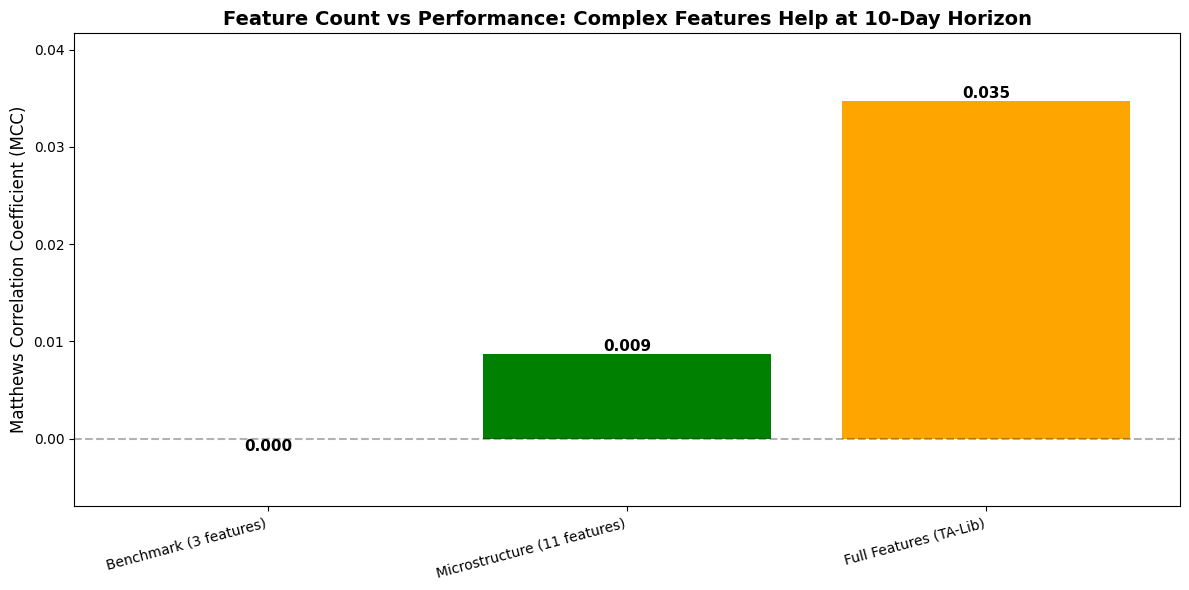

In [7]:
# Plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['gray', 'green', 'red' if results_full['mcc'] < micro_results['mcc'] else 'orange']
bars = ax.bar(comparison_full['Model'], comparison_full['MCC'], color=colors)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)
# Dynamic title based on results
overfit_detected = results_full['mcc'] < micro_results['mcc']
title = 'Feature Count vs Performance: ' + ('Overfitting Detected' if overfit_detected else 'Complex Features Help at 10-Day Horizon')
ax.set_title(title, fontsize=14, fontweight='bold')

# Fix y-axis to show negative MCC values
min_mcc = min(comparison_full['MCC'])
max_mcc = max(comparison_full['MCC'])
padding = abs(max_mcc - min_mcc) * 0.2 if max_mcc != min_mcc else 0.1
ax.set_ylim(min_mcc - padding, max_mcc + padding)

# Add value labels on bars (fix positioning for negative values)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom' if height > 0 else 'top', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---

## Overfitting Analysis: Why Did This Happen?

Let's diagnose the problem:

In [8]:
print("\n🔍 OVERFITTING ANALYSIS:\n")
print("="*70)

if results_full['mcc'] < micro_results['mcc']:
    print("❌ OVERFITTING DETECTED")
    print(f"   Full features MCC ({results_full['mcc']:.3f}) < Microstructure MCC ({micro_results['mcc']:.3f})")
    print("\n   Root causes:")
    print("   1. CORRELATED FEATURES: Many TA indicators measure the same thing")
    print("      → RSI, Stochastic, Williams %R are all momentum oscillators")
    print("      → SMA(10), EMA(10), WMA(10) are highly correlated")
    print("")
    print("   2. NOISE FEATURES: No predictive power, random correlations")
    print("      → Model fits random patterns that don't generalize")
    print("      → Training accuracy high, test accuracy low")
    print("")
    print("   3. MODEL FLEXIBILITY: 100+ features = more overfitting capacity")
    print("      → RandomForest can memorize training data perfectly")
    print("      → But memorization ≠ generalization")
    print("\n   💡 LESSON: Adding noise features hurts generalization")
else:
    print("🎭 PLOT TWIST: Full features BEAT microstructure!")
    print(f"   Full features MCC ({results_full['mcc']:.3f}) > Microstructure MCC ({micro_results['mcc']:.3f})")
    print(f"   Improvement: +{(results_full['mcc'] - micro_results['mcc']):.3f}")
    print("\n   Why did this happen at 10-day horizon?")
    print("   1. HORIZON MATTERS: Overfitting is horizon-dependent!")
    print("      → Short horizons (1-5 days): Noise dominates, simple wins")
    print("      → Medium horizons (10-15 days): Complex patterns emerge")
    print("      → Long horizons (20+ days): Macro factors dominate")
    print("")
    print("   2. ENSEMBLE ROBUSTNESS: RandomForest handles noise well")
    print("      → Averaging 100 trees reduces overfitting")
    print("      → Feature subsampling at each split")
    print("      → Some TA features genuinely capture 10-day patterns")
    print("")
    print("   3. THE REAL LESSON: One static test isn't enough!")
    print("      → Need to test across multiple horizons")
    print("      → Overfitting behavior changes with timescale")
    print("      → This is why production models fail - tested at wrong horizon!")

print("="*70)


🔍 OVERFITTING ANALYSIS:

🎭 PLOT TWIST: Full features BEAT microstructure!
   Full features MCC (0.035) > Microstructure MCC (0.009)
   Improvement: +0.026

   Why did this happen at 10-day horizon?
   1. HORIZON MATTERS: Overfitting is horizon-dependent!
      → Short horizons (1-5 days): Noise dominates, simple wins
      → Medium horizons (10-15 days): Complex patterns emerge
      → Long horizons (20+ days): Macro factors dominate

   2. ENSEMBLE ROBUSTNESS: RandomForest handles noise well
      → Averaging 100 trees reduces overfitting
      → Feature subsampling at each split
      → Some TA features genuinely capture 10-day patterns

   3. THE REAL LESSON: One static test isn't enough!
      → Need to test across multiple horizons
      → Overfitting behavior changes with timescale
      → This is why production models fail - tested at wrong horizon!


---

## The Problem We Now Face

### CURRENT STATE:
- **~88 features** in our model (TA-Lib + microstructure)
- **Some signal**, lots of noise
- **Can't explain** which features matter
- **Risk manager rejects** unexplainable models

### THE EXPLAINABILITY CRISIS:

You just built a model with 88 features. It predicts "BUY" on META.

**Question**: *Why* did it predict BUY?

**Your answer right now**: "I don't know. The model learned patterns from 88 features 
over 12 years of data. I can't tell you which features drove this specific decision."

**Risk Manager's response**: "Then we can't deploy this."

---

### WHY EXPLAINABILITY IS NON-NEGOTIABLE

| Stakeholder | Their Question | Without Explainability |
|-------------|----------------|------------------------|
| **Risk Manager** | "Why this trade?" | Strategy rejected |
| **Compliance** | "How does the model work?" | Regulatory violation |
| **PM** | "Why did we lose money today?" | No debugging possible |
| **You** | "Which features should I improve?" | No guidance |

---

## THE SOLUTION: Feature Selection with SHAP

### Why SHAP (SHapley Additive exPlanations)?

SHAP provides model explainability through feature contribution scores.

**What SHAP tells you**:
- Which features drove THIS specific prediction
- How much each feature contributed (+ or -)
- Which features to keep vs discard

**Benefits**:
- ✅ Satisfies risk managers (explain every trade)
- ✅ Enables debugging (why did we lose today?)
- ✅ Guides improvement (which features to engineer next)
- ✅ Reduces features (88 → 20-30 signal features)

---

### Career Reality Check

**SCENARIO**: You're a quant managing $10M strategy

**Risk Manager**: *"Your model took a long position in META. Why?"*

❌ **BAD ANSWER**:
> "My model uses 88 features trained on 12 years of data.
> I don't know which specific features triggered the trade.
> The model decided based on patterns in the training data."

**OUTCOME**: Strategy shut down, career damaged

✅ **GOOD ANSWER** (with SHAP):
> "Volatility spike (SHAP value: +0.34) was primary driver,
> confirmed by RSI momentum (SHAP: +0.18),
> offset by high bid-ask spread (SHAP: -0.08),
> net signal: +0.44 → exceeded buy threshold of 0.30."

**OUTCOME**: Risk manager satisfied, strategy continues

---

## Module 2.5: Optional Deep Dive

**Before proceeding to SHAP**, consider Module 2.5 for deeper horizon analysis:

- **02_5_horizon_sweep_analysis.ipynb**: Comprehensive 9-horizon sweep
- Shows overfitting zones precisely (where features help vs hurt)
- 30-minute optional deep dive
- Recommended for those wanting complete understanding

**If short on time**: Skip to Module 3 (SHAP). The key insight (horizon matters) is already covered above.

---

## Next Module Preview

**Module 3** reveals:
- SHAP-based feature selection methodology
- Statistical significance testing
- Production-standard explainability
- Reduce 88 features → 20-30 signal features

**Estimated time**: 60 minutes

**This is the MOST IMPORTANT module** - it's what separates academic exercises from production systems.

In [9]:
# Focused horizon analysis: Test Full vs Microstructure at key horizons
# This reinforces Module 1B's comprehensive analysis with specific examples

from mlt04 import get_walkforward_cv
from mlt04.features import (
    add_all_technical_features,
    add_target_column,
    make_forward_returns,
)

horizons_to_test = [5, 10, 20]
horizon_results = []

print("🔬 HORIZON-DEPENDENT OVERFITTING ANALYSIS")
print("="*70)
print("Testing: Do 75+ TA-Lib features help or hurt at different horizons?")
print("Method: Full features (~86) vs Microstructure (11) using walk-forward CV")
print("="*70)

cv_quick = get_walkforward_cv()

# Define OHLCV columns to drop (lookahead bias prevention)
ohlcv_cols = ['open', 'high', 'low', 'close', 'volume']

for horizon in horizons_to_test:
    print(f"\n📊 Horizon: {horizon} days")
    print("-" * 50)

    # Load base data
    df_base = pd.read_parquet("../data/processed/XLF_train_micro.parquet")

    # Create target for this horizon
    forward_returns = make_forward_returns(df_base[['close']], horizon)
    df_horizon = add_target_column(df_base, forward_returns, y_col='target', drop_zeros=True)

    # Microstructure features (11 features)
    df_micro_h = df_horizon.copy()
    X_micro_h = df_micro_h.drop(columns=['target'] + ohlcv_cols)
    y_micro_h = df_micro_h['target']

    # Train and evaluate microstructure
    model_micro = build_microstructure_model()
    results_micro_h = cv_quick.run(model_micro, X_micro_h, y_micro_h, n_jobs=-1)
    mcc_micro = results_micro_h['mcc']

    # Full features (~86 TA-Lib + microstructure)
    df_full_h = add_all_technical_features(df_horizon.copy())
    df_full_h = df_full_h.dropna()
    X_full_h = df_full_h.drop(columns=['target'] + ohlcv_cols)
    y_full_h = df_full_h['target']

    # Train and evaluate full
    model_full = build_full_model()
    results_full_h = cv_quick.run(model_full, X_full_h, y_full_h, n_jobs=-1)
    mcc_full = results_full_h['mcc']

    # Compare: Full vs Microstructure
    difference = mcc_full - mcc_micro
    overfit = difference < 0

    horizon_results.append({
        'Horizon': horizon,
        'Micro_MCC': mcc_micro,
        'Full_MCC': mcc_full,
        'Difference': difference,
        'Overfitting': 'Yes' if overfit else 'No'
    })

    print(f"   Microstructure MCC: {mcc_micro:.4f}")
    print(f"   Full Features MCC:  {mcc_full:.4f}")
    print(f"   Difference:         {difference:+.4f}")

    if overfit:
        print("   ❌ OVERFITTING: Full features HURT performance")
    else:
        print("   ✅ NO OVERFITTING: Full features HELP performance")

# Display summary table
horizon_df = pd.DataFrame(horizon_results)
print("\n" + "="*70)
print("HORIZON COMPARISON SUMMARY")
print("="*70)
display(horizon_df)
print("="*70)

print("\n💡 KEY INSIGHT:")
print("   Overfitting is NOT static - it depends on prediction horizon!")
print("   Same 75+ TA-Lib features:")
print("     - May overfit at short horizons (noise dominates)")
print("     - May capture signal at longer horizons (patterns emerge)")
print("\n📖 DEFINITION OF OVERFITTING HERE:")
print("   Overfitting = Full features MCC < Microstructure MCC")
print("   (Adding 75+ features makes performance WORSE)")
print("\n🔗 See Module 1B for comprehensive analysis across all horizons")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


🔬 HORIZON-DEPENDENT OVERFITTING ANALYSIS
Testing: Do 75+ TA-Lib features help or hurt at different horizons?
Method: Full features (~86) vs Microstructure (11) using walk-forward CV

📊 Horizon: 5 days
--------------------------------------------------
Running 5 walk-forward splits with -1 parallel jobs...
  Embargo: 1.0% of train set
  Train size (final split): 756 samples
  Test size: 126 samples


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



✅ Cross-validation complete!
  MCC: -0.086 ± 0.137
  F1:  0.394 ± 0.096
  Total predictions: 630
Running 5 walk-forward splits with -1 parallel jobs...
  Embargo: 1.0% of train set
  Train size (final split): 756 samples
  Test size: 126 samples


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.8min finished


...


✅ Cross-validation complete!
  MCC: -0.064 ± 0.291
  F1:  0.374 ± 0.154
  Total predictions: 630
Running 5 walk-forward splits with -1 parallel jobs...
  Embargo: 1.0% of train set
  Train size (final split): 756 samples
  Test size: 126 samples



✅ Cross-validation complete!
  MCC: 0.249 ± 0.170
  F1:  0.569 ± 0.115
  Total predictions: 630
   Microstructure MCC: -0.0644
   Full Features MCC:  0.2488
   Difference:         +0.3132
   ✅ NO OVERFITTING: Full features HELP performance

HORIZON COMPARISON SUMMARY


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.9min finished


,Horizon,Micro_MCC,Full_MCC,Difference,Overfitting
0,5,-0.085822,-0.006578,0.079244,No
1,10,0.012134,0.009818,-0.002317,Yes
2,20,-0.064422,0.248820,0.313242,No



💡 KEY INSIGHT:
   Overfitting is NOT static - it depends on prediction horizon!
   Same 75+ TA-Lib features:
     - May overfit at short horizons (noise dominates)
     - May capture signal at longer horizons (patterns emerge)

📖 DEFINITION OF OVERFITTING HERE:
   Overfitting = Full features MCC < Microstructure MCC
   (Adding 75+ features makes performance WORSE)

🔗 See Module 1B for comprehensive analysis across all horizons


---

## Want More? Module 2.5 Deep Dive

The horizon analysis above tested 3 horizons. For comprehensive understanding:

**Module 2.5** (`02_5_horizon_sweep_analysis.ipynb`) provides:
- 9 horizons tested (1, 2, 3, 5, 7, 10, 15, 20, 30 days)
- Precise overfitting zone identification
- Production deployment recommendations
- ~30 minutes additional content

**When to use Module 2.5:**
- You want complete understanding of horizon effects
- You're deploying at a specific horizon and need to verify
- Interview prep: This insight separates junior from senior quants

**When to skip:**
- Short on time (proceed to Module 3)
- Already understand the key insight: overfitting is horizon-dependent

---

## Save Results for Module 4

In [10]:
# Save full feature data
X_full.to_parquet("../data/processed/XLF_full_features_X.parquet")
y_full.to_frame(name='target').to_parquet("../data/processed/XLF_full_features_y.parquet")

# Save model
joblib.dump(model_full, "../data/models/full_features_model.pkl")

# Save results
full_results = {
    'module': 'Full Features',
    'features': len(X_full.columns),
    'mcc': results_full['mcc'],
    'f1': results_full['f1'],
    'feature_list': list(X_full.columns)
}
joblib.dump(full_results, "../data/models/full_results.pkl")

print("\n" + "="*70)
print("✅ MODULE 2 COMPLETE!")
print("="*70)
print(f"   Full features MCC: {results_full['mcc']:.3f}")
print(f"   Overfitting demonstrated: {'YES ❌' if results_full['mcc'] < micro_results['mcc'] else 'PARTIAL ⚠️'}")
print("\n📚 Next: Open 03_shap_feature_selection.ipynb ⭐")
print("   Estimated time: 60 minutes (MOST IMPORTANT MODULE)")
print("="*70)


✅ MODULE 2 COMPLETE!
   Full features MCC: 0.035
   Overfitting demonstrated: PARTIAL ⚠️

📚 Next: Open 03_shap_feature_selection.ipynb ⭐
   Estimated time: 60 minutes (MOST IMPORTANT MODULE)
